## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Thu Oct 31 05:18:38 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
import os

HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install Segment Anything Model (SAM) and other dependencies

In [5]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

  Preparing metadata (setup.py) ... done


In [6]:
# !pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0
!pip install -q dataclasses-json supervision==0.23.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.7 MB/s eta 0:00:00


### Download SAM weights

In [7]:
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [8]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import cv2, torch
import torch
import supervision as sv
import matplotlib.pyplot as plt

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/content/weights/sam_vit_h_4b8939.pth ; exist: True


## Load Model

In [10]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [11]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [90]:
# IMAGE_PATH = '/content/images/1.png'
# IMAGE_PATH = '/content/images/2.png'
# IMAGE_PATH = '/content/images/3.png'
# IMAGE_PATH = '/content/images/4.png'
# IMAGE_PATH = '/content/images/5.png'
IMAGE_PATH = '/content/images/6.png'

### Generate masks with SAM

In [91]:
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

sam_result = mask_generator.generate(image_rgb)

### Output format

In [92]:
print(sam_result[0].keys())

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

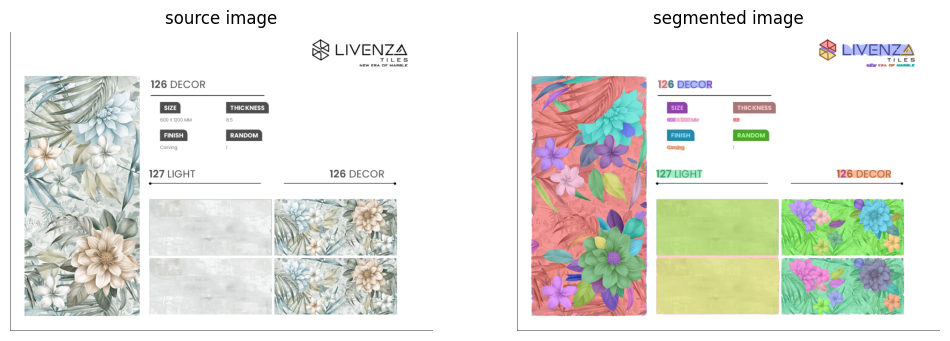

In [93]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_sam(sam_result=sam_result)

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

In [94]:
[
    mask['area']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
][:10]

[109692, 109071, 56234, 27386, 27381, 27309, 27104, 27078, 26882, 12705]

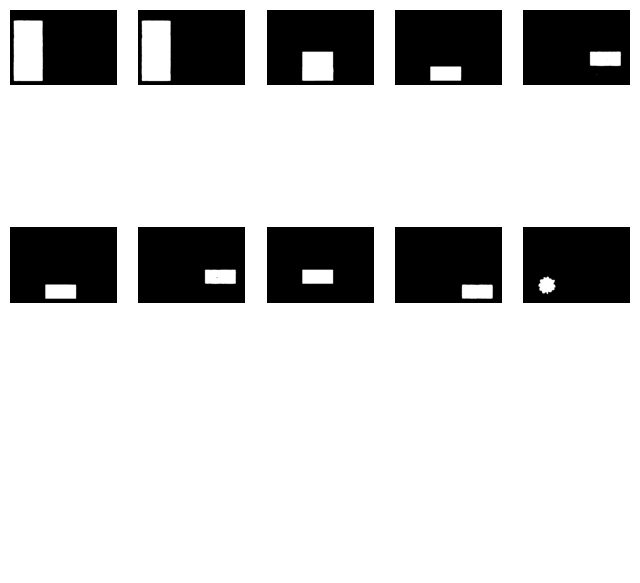

In [95]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
][:10]

sv.plot_images_grid(
    images=masks,
    grid_size=(3, int(len(masks) / 2)),
    size=(8, 8)
)

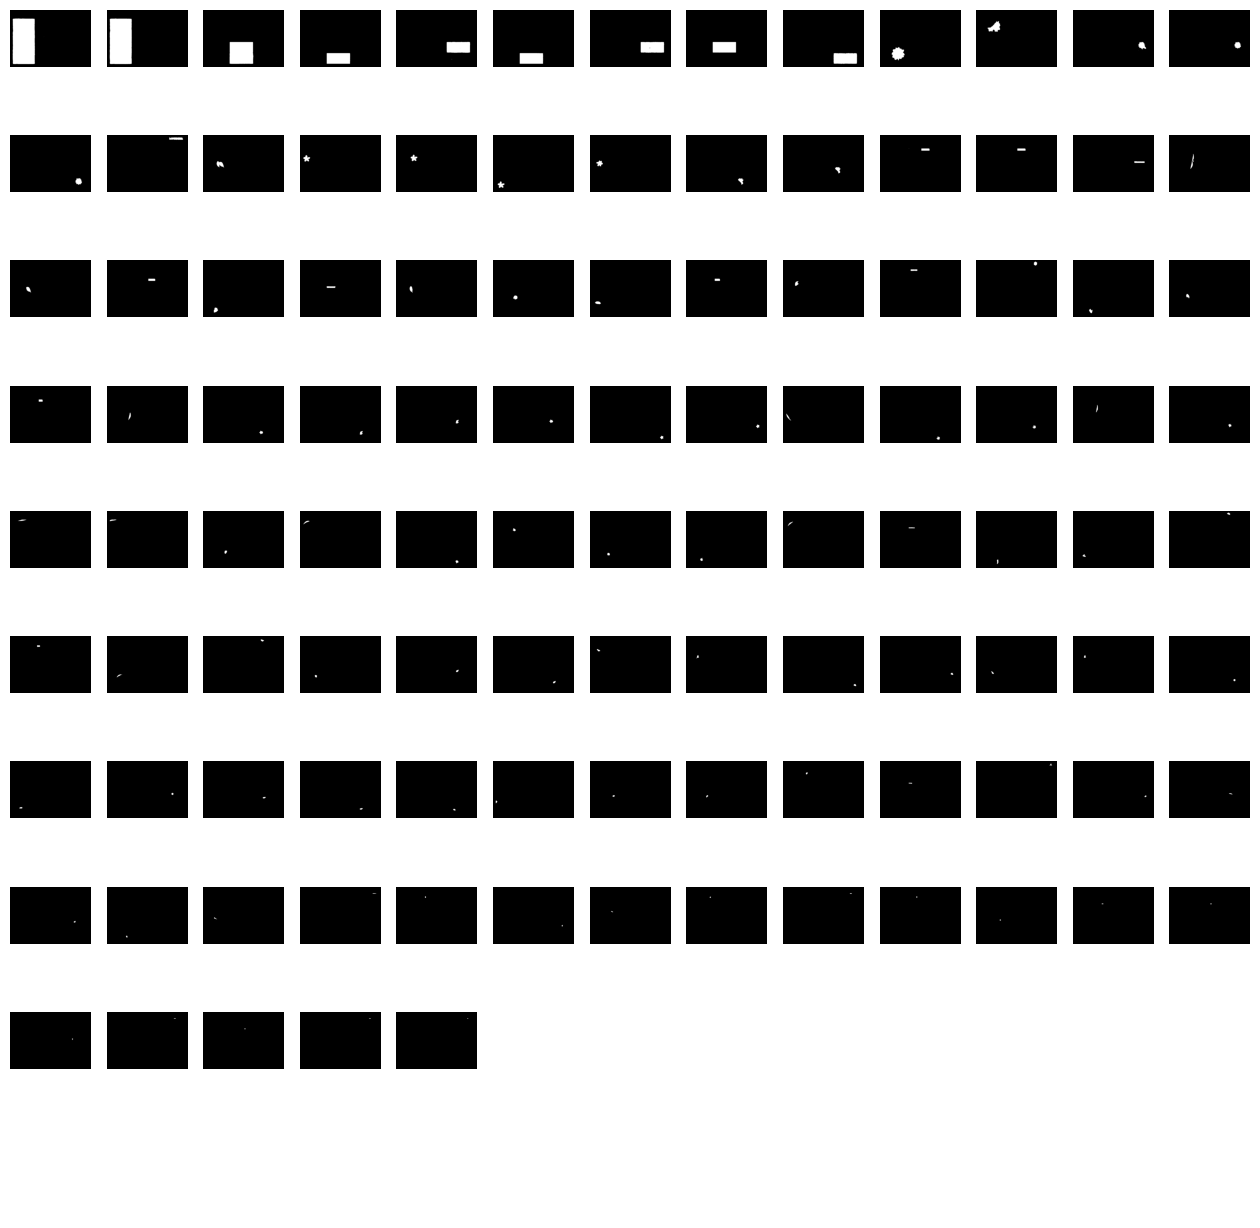

In [96]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks,
    grid_size=(10, int(len(masks) / 8)),
    size=(16, 16)
)

# Crop Tiles From Images

In [99]:
output_dir = '/content/cropped_masks'
os.makedirs(output_dir, exist_ok=True)

In [100]:
sam_result = [
    mask
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

In [101]:
sam_result[0]['area']

109692

In [102]:
# List to hold cropped images
cropped_images = []

# Iterate over each mask and crop it from the source image if it meets the area condition
for i, mask_data in enumerate(sam_result):
    # Check if the area is within the specified range
    # if 45000 <= mask_data['area'] <= 50000:
    if 25000 <= mask_data['area'] <= 110000:
        # Get the bounding box for the mask and convert to integers
        x, y, w, h = map(int, mask_data['bbox'])

        # Crop the region within the bounding box
        cropped_mask = image_bgr[y:y+h, x:x+w]

        # Append the cropped image to the list
        cropped_images.append(cropped_mask)

        # Save the cropped mask as an image (optional)
        cv2.imwrite(f"{output_dir}/mask_{i}.png", cropped_mask)
        print(f"Mask {i} with area {mask_data['area']} saved.")

Mask 0 with area 109692 saved.
Mask 1 with area 109071 saved.
Mask 2 with area 56234 saved.
Mask 3 with area 27386 saved.
Mask 4 with area 27381 saved.
Mask 5 with area 27309 saved.
Mask 6 with area 27104 saved.
Mask 7 with area 27078 saved.
Mask 8 with area 26882 saved.


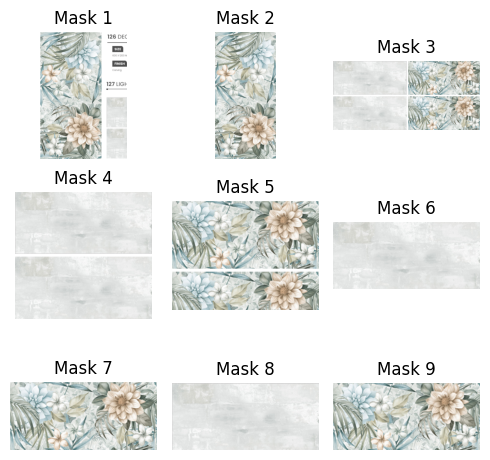

In [103]:
# Plot the cropped images in a grid
num_images = len(cropped_images)
cols = 3
rows = (num_images // cols) + (num_images % cols > 0)

fig, axs = plt.subplots(rows, cols, figsize=(5, 5))

for idx, cropped_image in enumerate(cropped_images):
    ax = axs[idx // cols, idx % cols]
    ax.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title(f"Mask {idx + 1}")

# Hide any unused subplots
for idx in range(num_images, rows * cols):
    fig.delaxes(axs[idx // cols, idx % cols])

plt.tight_layout()
plt.show()

In [104]:
import shutil
import os

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f"{output_dir} has been deleted.")
else:
    print(f"{output_dir} does not exist.")

/content/cropped_masks has been deleted.
